In [40]:
import numpy as np
import pandas as pd
data = {
    'car_name':  ['Maruti Swift', 'Honda City', 'Ferrari 488', 'Hyundai i20',
                  'Toyota Innova', 'Maruti Baleno', 'BMW 5 Series', 'Tata Nexon',
                  'Ferrari Roma', 'Honda Amaze', 'BMW 3 Series', 'Hyundai Creta'],
    'car_age':   [5, 3, 2, 7, 4, 6, 3, 5, 1, 4, 6, 2],
    'km_driven': [45000, 28000, 5000, 72000, 38000, 55000, 22000, 48000,
                  3000, 35000, 60000, 18000],
    'engine_cc': [1197, 1498, 3902, 1197, 2694, 1197, 1998, 1497,
                  3855, 1199, 1998, 1497],
    'fuel':      ['Petrol', 'Diesel', 'Petrol', 'Petrol', 'Diesel',
                  'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Petrol', 'Diesel'],
    'brand':     ['Maruti', 'Honda', 'Ferrari', 'Hyundai', 'Toyota',
                  'Maruti', 'BMW', 'Tata', 'Ferrari', 'Honda', 'BMW', 'Hyundai'],
    'price':     [5.2, 8.4, 220.0, 3.8, 12.5, 4.9, 38.0, 7.1,
                  210.0, 6.8, 35.0, 11.2]
}

df = pd.DataFrame(data)
df

,car_name,car_age,km_driven,engine_cc,fuel,brand,price
0,Maruti Swift,5,45000,1197,Petrol,Maruti,5.2
1,Honda City,3,28000,1498,Diesel,Honda,8.4
2,Ferrari 488,2,5000,3902,Petrol,Ferrari,220.0
3,Hyundai i20,7,72000,1197,Petrol,Hyundai,3.8
4,Toyota Innova,4,38000,2694,Diesel,Toyota,12.5
5,Maruti Baleno,6,55000,1197,Petrol,Maruti,4.9
6,BMW 5 Series,3,22000,1998,Petrol,BMW,38.0
7,Tata Nexon,5,48000,1497,Diesel,Tata,7.1
8,Ferrari Roma,1,3000,3855,Petrol,Ferrari,210.0
9,Honda Amaze,4,35000,1199,Petrol,Honda,6.8


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   car_name   12 non-null     object 
 1   car_age    12 non-null     int64  
 2   km_driven  12 non-null     int64  
 3   engine_cc  12 non-null     int64  
 4   fuel       12 non-null     object 
 5   brand      12 non-null     object 
 6   price      12 non-null     float64
dtypes: float64(1), int64(3), object(3)
memory usage: 804.0+ bytes


In [42]:
# Preprocessing
df = df.drop('car_name',axis = 1)
df.columns

Index(['car_age', 'km_driven', 'engine_cc', 'fuel', 'brand', 'price'], dtype='object')

In [43]:
num_cols = df.select_dtypes(include = np.number).columns
num_cols

Index(['car_age', 'km_driven', 'engine_cc', 'price'], dtype='object')

In [44]:
cat_cols = df.select_dtypes(include = 'object').columns
cat_cols

Index(['fuel', 'brand'], dtype='object')

In [45]:
df = pd.get_dummies(df, columns = cat_cols, drop_first = True)
df.head()

,car_age,km_driven,engine_cc,price,fuel_Petrol,brand_Ferrari,brand_Honda,brand_Hyundai,brand_Maruti,brand_Tata,brand_Toyota
0,5,45000,1197,5.2,True,False,False,False,True,False,False
1,3,28000,1498,8.4,False,False,True,False,False,False,False
2,2,5000,3902,220.0,True,True,False,False,False,False,False
3,7,72000,1197,3.8,True,False,False,True,False,False,False
4,4,38000,2694,12.5,False,False,False,False,False,False,True


In [46]:
print(len(df.columns))
print(df.columns)

11
Index(['car_age', 'km_driven', 'engine_cc', 'price', 'fuel_Petrol',
       'brand_Ferrari', 'brand_Honda', 'brand_Hyundai', 'brand_Maruti',
       'brand_Tata', 'brand_Toyota'],
      dtype='object')


In [48]:
X = df.drop(columns = ['price'])
y = df['price']

In [ ]:
np.random.seed(42) # seed makes the random numbers are fixed even if we run the code multiple times
print(np.random.permutation(5))

[1 4 2 0 3]


In [ ]:
np.random.seed(10) # any number can be used as seed, but using the same seed will give the same random numbers otherwise different random numbers will be generated
print(np.random.permutation(5))

[2 3 0 4 1]


In [94]:
np.random.seed(42)
indices = np.random.permutation(len(df))
'''
or
indices = np.arange(len(df))
np.random.shuffle(indices)
'''
split = int(0.8* len(X))
train_idx = indices[:split]
test_idx = indices[split:]

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

In [95]:
X_train.shape, X_test.shape

((9, 10), (3, 10))

In [96]:
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
y_train.shape, y_test.shape

((9,), (3,))

In [97]:
print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 9
Test size : 3


In [106]:
mean = X_train.mean()
std = X_train.std()

std = std.replace(0, 1)
std = std.fillna(1)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print("x train mean\n", X_train_scaled.mean())
print("x train std\n", X_train_scaled.std())

x train mean
 car_age          1.017704e-16
km_driven       -7.401487e-17
engine_cc        7.401487e-17
fuel_Petrol      7.401487e-17
brand_Ferrari    3.700743e-17
brand_Honda      3.700743e-17
brand_Hyundai   -6.167906e-18
brand_Maruti     3.700743e-17
brand_Tata       0.000000e+00
brand_Toyota     0.000000e+00
dtype: float64
x train std
 car_age          1.0
km_driven        1.0
engine_cc        1.0
fuel_Petrol      1.0
brand_Ferrari    1.0
brand_Honda      1.0
brand_Hyundai    1.0
brand_Maruti     1.0
brand_Tata       0.0
brand_Toyota     1.0
dtype: float64


In [105]:
print("x test mean\n", X_test_scaled.mean())
print("x test std\n", X_test_scaled.std())

x test mean
 car_age          7.396003e-01
km_driven        7.594098e-01
engine_cc       -4.965912e-01
fuel_Petrol      7.401487e-17
brand_Ferrari   -5.039526e-01
brand_Honda     -5.039526e-01
brand_Hyundai    6.666667e-01
brand_Maruti    -5.039526e-01
brand_Tata       3.333333e-01
brand_Toyota    -3.333333e-01
dtype: float64
x test std
 car_age          1.109400
km_driven        1.229588
engine_cc        0.364574
fuel_Petrol      1.154701
brand_Ferrari    0.000000
brand_Honda      0.000000
brand_Hyundai    1.732051
brand_Maruti     0.000000
brand_Tata       0.577350
brand_Toyota     0.000000
dtype: float64


In [107]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("Predicted values\n", y_pred)

Predicted values
 [14.93535455  0.74707629 44.6074745 ]


In [109]:
model.coef_

array([ 19.08119593, -22.13595804,  37.61111985,   2.78293496,
        45.40076655,  -3.16133684,  -1.54511818,  -3.7047005 ,
         0.        , -14.43130984])

In [110]:
sample = X_test_scaled.iloc[0]
print("Sample features\n", sample)

Sample features
 car_age          0.739600
km_driven        0.792190
engine_cc       -0.556951
fuel_Petrol     -1.333333
brand_Ferrari   -0.503953
brand_Honda     -0.503953
brand_Hyundai   -0.333333
brand_Maruti    -0.503953
brand_Tata       1.000000
brand_Toyota    -0.333333
Name: 7, dtype: float64


In [112]:
manual_pred = np.dot(sample.values, model.coef_) + model.intercept_
manual_pred

14.935354550405904

In [113]:
manual_pred2 = np.dot(X_test_scaled.iloc[1].values, model.coef_) + model.intercept_
manual_pred2

0.7470762907791553

In [114]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 5.831917586715739
Root Mean Squared Error: 6.1744593118187945
R-squared: 0.8393157388801069


In [115]:
# manually calculating the metrics
errors = []
for i in range(len(y_test)):
    err = abs(y_test.iloc[i] - y_pred[i])
    errors.append(err)
mae = sum(errors) / len(errors)
print("Manually calculated MAE:", mae)

Manually calculated MAE: 5.831917586715739


In [116]:
sq_errs = []
for i in range(len(y_test)):
    err = (y_test.iloc[i] - y_pred[i]) ** 2
    sq_errs.append(err)
rmse = np.sqrt(sum(sq_errs) / len(sq_errs))
print("Manually calculated RMSE:", rmse)

Manually calculated RMSE: 6.1744593118187945


In [117]:
sq_mn = []
y_mean = sum(y_test) / len(y_test)
for i in range(len(y_test)):
    err = (y_test.iloc[i] - y_mean) ** 2
    sq_mn.append(err)

r2 = 1 - (sum(sq_errs) / sum(sq_mn))
print("Manually calculated R-squared:", r2)

Manually calculated R-squared: 0.8393157388801069


In [122]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


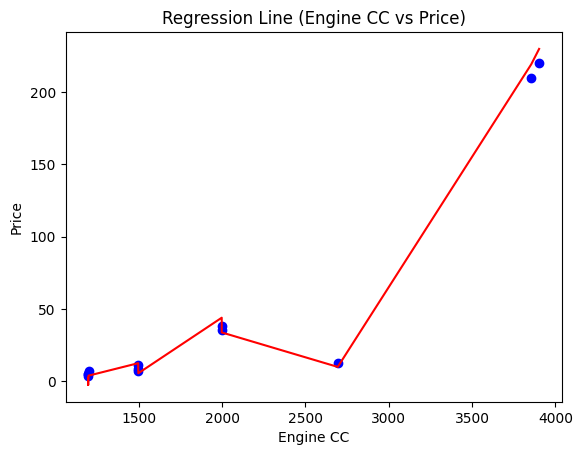

In [123]:
import matplotlib.pyplot as plt

# Use original (unscaled) values for visualization clarity
plt.scatter(X['engine_cc'], y, color='blue')

# Predict using model
y_pred_full = model.predict(X_train_scaled)

# For visualization, sort values
sorted_idx = X['engine_cc'].argsort()

plt.plot(X['engine_cc'].iloc[sorted_idx],
         model.predict(scaler.transform(X.iloc[sorted_idx])),
         color='red')

plt.xlabel("Engine CC")
plt.ylabel("Price")
plt.title("Regression Line (Engine CC vs Price)")

plt.show()

# Practice

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('datasets\\cardekho_dataset.csv')
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [3]:
df = df.drop(columns={'Unnamed: 0'})

In [5]:
df = df.drop(columns=['car_name', 'model'])
df['brand'].value_counts

<bound method IndexOpsMixin.value_counts of 0          Maruti
1         Hyundai
2         Hyundai
3          Maruti
4            Ford
           ...   
15406     Hyundai
15407      Maruti
15408       Skoda
15409    Mahindra
15410       Honda
Name: brand, Length: 15411, dtype: object>

In [6]:
df['brand'].value_counts()

brand
Maruti           4992
Hyundai          2982
Honda            1485
Mahindra         1011
Toyota            793
Ford              790
Volkswagen        620
Renault           536
BMW               439
Tata              430
Mercedes-Benz     337
Skoda             334
Audi              192
Datsun            170
Jaguar             59
Land Rover         51
Jeep               41
Kia                32
Porsche            21
Volvo              20
MG                 19
Mini               17
Nissan             11
Lexus              10
Isuzu               8
Bentley             3
Maserati            2
ISUZU               2
Ferrari             1
Mercedes-AMG        1
Rolls-Royce         1
Force               1
Name: count, dtype: int64

In [10]:
brand_counts = df['brand'].value_counts()
rare_brands = brand_counts[brand_counts < 100].index
df['brand'] = df['brand'].replace(rare_brands, 'others')
df['brand'].value_counts()

brand
Maruti           4992
Hyundai          2982
Honda            1485
Mahindra         1011
Toyota            793
Ford              790
Volkswagen        620
Renault           536
BMW               439
Tata              430
Mercedes-Benz     337
Skoda             334
others            300
Audi              192
Datsun            170
Name: count, dtype: int64

In [ ]:
df.columns

Index(['brand', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type',
       'transmission_type', 'mileage', 'engine', 'max_power', 'seats',
       'selling_price'],
      dtype='object')

In [12]:
df['seller_type'].value_counts()

seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64

In [26]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['brand', 'seller_type', 'fuel_type', 'transmission_type'], dtype='object')

In [14]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [15]:
np.set_printoptions(suppress=True)

In [18]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [19]:
df['selling_price'].min()

40000

In [22]:
df['seats'] = np.where(df['seats'] == 0, df['seats'].mode()[0], df['seats'])

In [23]:
df['seats'].min()

2

In [27]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'selling_price'],
      dtype='object')

[]

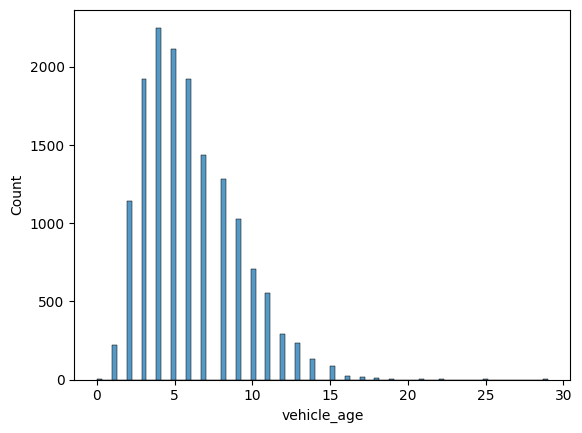

In [ ]:
import seaborn as sns
sns.histplot(data=df, x=df['vehicle_age'])

plt.plot()

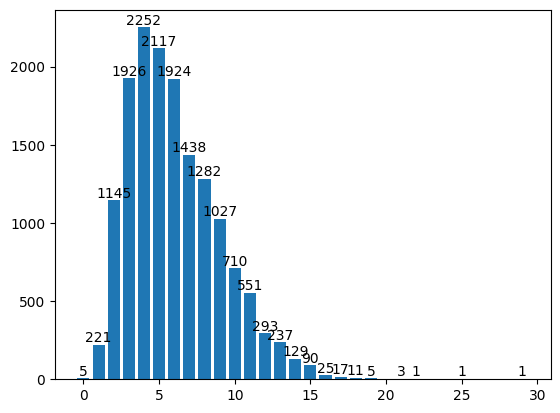

In [32]:
counts = df['vehicle_age'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values)
ax.bar_label(bars)
plt.show()

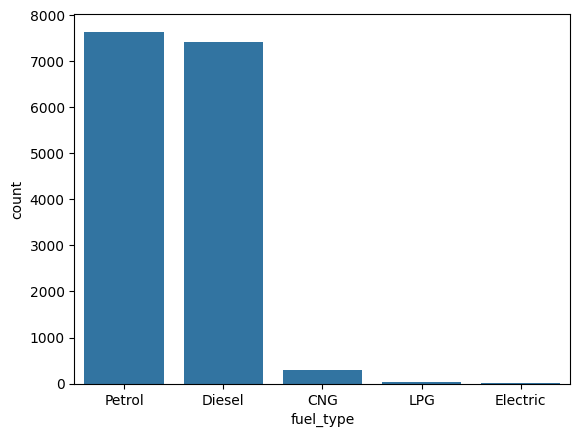

In [34]:
sns.countplot(data=df, x='fuel_type')
plt.show()

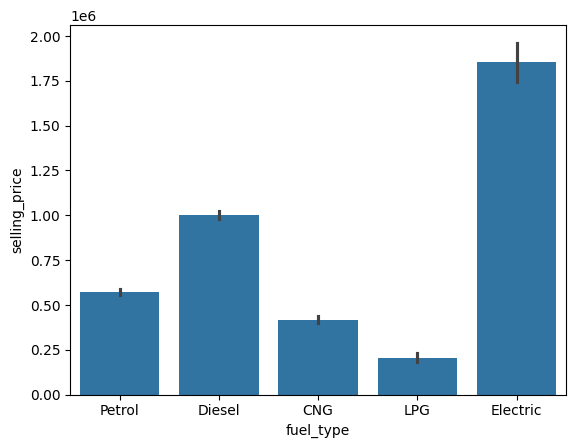

In [36]:
sns.barplot(data=df, x='fuel_type', y='selling_price')
plt.show()

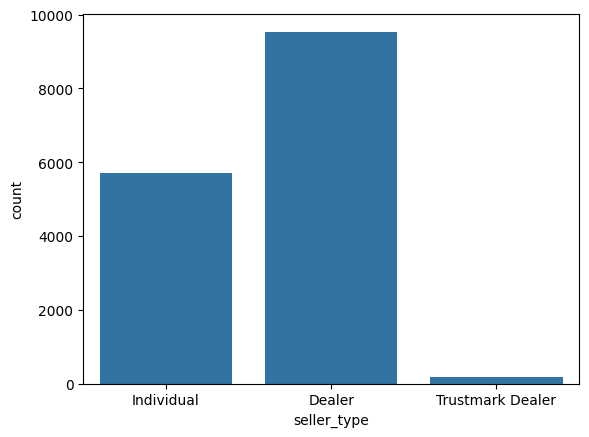

In [37]:
sns.countplot(data=df, x ='seller_type')
plt.show()

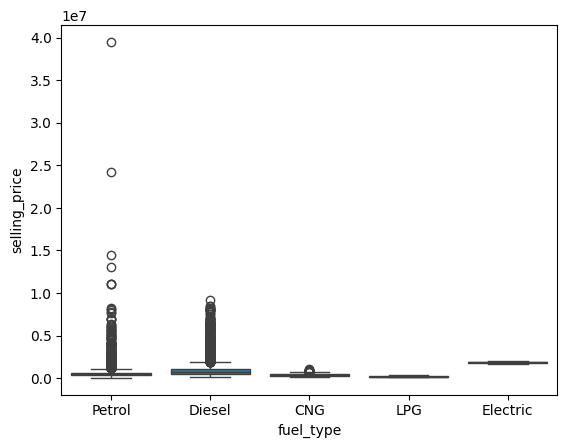

In [40]:
sns.boxplot(data=df, y='selling_price', x='fuel_type')
plt.show()

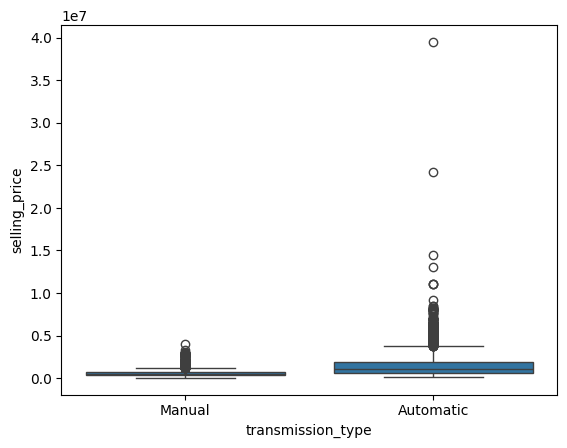

In [41]:
sns.boxplot(data=df, y='selling_price', x='transmission_type')
plt.show()

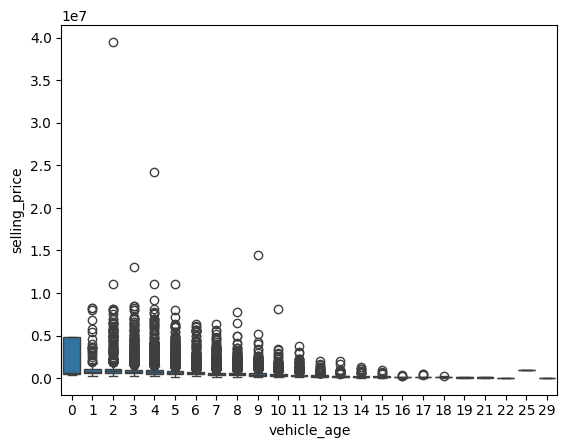

In [42]:
sns.boxplot(data=df, y='selling_price', x='vehicle_age')
plt.show()

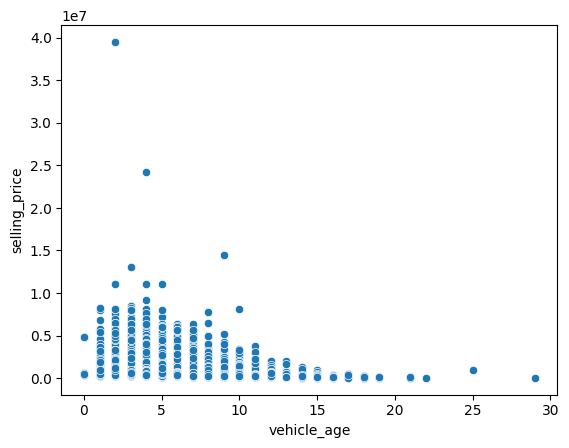

In [43]:
sns.scatterplot(data=df,x='vehicle_age', y = 'selling_price')
plt.show()

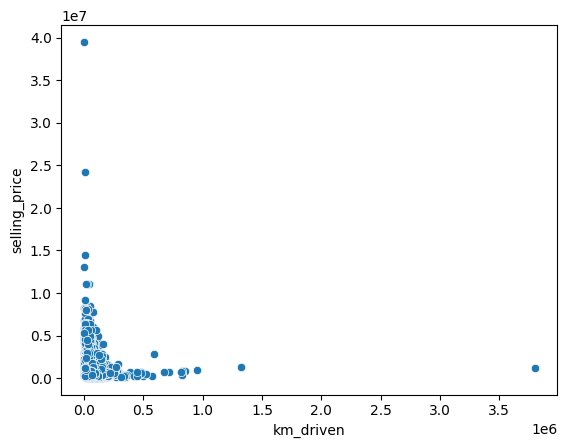

In [44]:
sns.scatterplot(data=df,x='km_driven', y = 'selling_price')
plt.show()

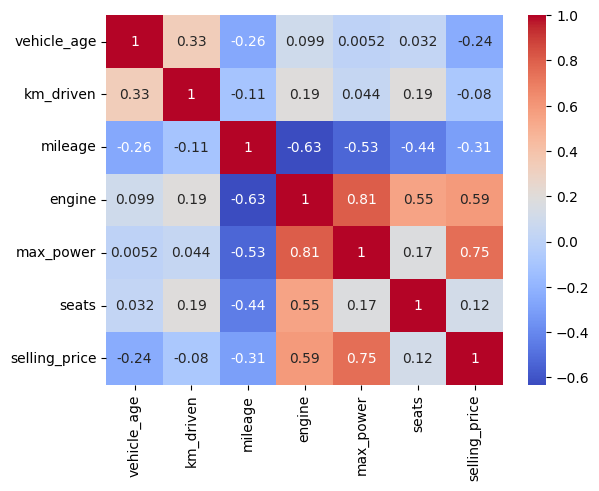

In [46]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Train: 12328 || Test: 3083


In [51]:
df = pd.read_csv('datasets\\cardekho_dataset.csv')
df = df.drop(columns=['Unnamed: 0', 'car_name', 'model'])
brand_counts = df['brand'].value_counts()
rare_brands = brand_counts[brand_counts < 100].index
df['brand'] = df['brand'].replace(rare_brands, 'others')
df['seats'] = np.where(df['seats'] == 0, df['seats'].mode()[0], df['seats'])
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_cols = ['vehicle_age', 'km_driven','mileage','engine','max_power','seats']
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])
X = df.drop('selling_price', axis=1)
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(y_train)} || Test: {len(y_test)}')
from sklearn.linear_model import Ridge, Lasso
models = {
    'LinearRegression': LinearRegression(),
    'RidgeRegression' : Ridge(alpha=1.0, max_iter=1000),
    'LassoRegression' : Lasso(alpha=0.1, max_iter=10000)
}
import time
results = []
trained_pipes = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0
    y_pred = pipe.predict(X_test)
    results.append({
        'Model':model,
        'mse': mean_squared_error(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': root_mean_squared_error(y_test, y_pred),
        'r2': r2_score(y_test, y_pred)
    }
    )
    trained_pipes[name] = pipe
result_df = pd.DataFrame(results)
print('+'*80)
print(result_df.round(4).to_string(index=False))

Train: 12328 || Test: 3083
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
                           Model          mse         mae        rmse    r2
              LinearRegression() 2.160258e+11 239101.9074 464785.7221 0.713
            Ridge(max_iter=1000) 2.160689e+11 239163.4519 464832.1094 0.713
Lasso(alpha=0.1, max_iter=10000) 2.160259e+11 239102.2266 464785.9175 0.713


C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.962e+14, tolerance: 9.998e+11
  model = cd_fast.enet_coordinate_descent(
